# 06 — XGBoost Optimisé : Visualisation & Performance
Ce notebook contient les graphiques avancés de performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

plt.style.use('ggplot')


In [2]:
df = pd.read_csv('../features/ml_dataset.csv').dropna(subset=['result'])
features = ['home_elo', 'away_elo', 'elo_diff', 'home_form_5', 'away_form_5', 'home_avg_overall', 'away_avg_overall', 'odds_prob_home', 'odds_prob_draw', 'odds_prob_away']
X, y = df[features].fillna(0), LabelEncoder().fit_transform(df['result'])

X_train, y_train = X[df['season'] != '2024/25'], y[df['season'] != '2024/25']
X_test, y_test = X[df['season'] == '2024/25'], y[df['season'] == '2024/25']

model = xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, eval_metric='mlogloss')
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## 1. Courbe d'Apprentissage (Loss Curve)
Indispensable pour vérifier que le modèle ne sur-apprend pas (overfitting).

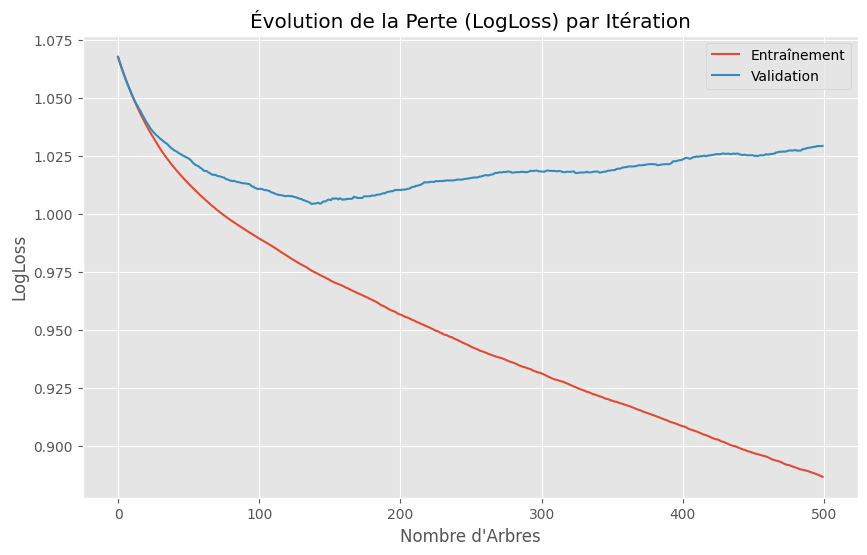

In [3]:
results = model.evals_result()
plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['mlogloss'], label='Entraînement')
plt.plot(results['validation_1']['mlogloss'], label='Validation')
plt.title('Évolution de la Perte (LogLoss) par Itération')
plt.xlabel('Nombre d\'Arbres')
plt.ylabel('LogLoss')
plt.legend()
plt.show()

## 2. Matrice de Confusion (Heatmap)
Visualisation précise des erreurs par classe.

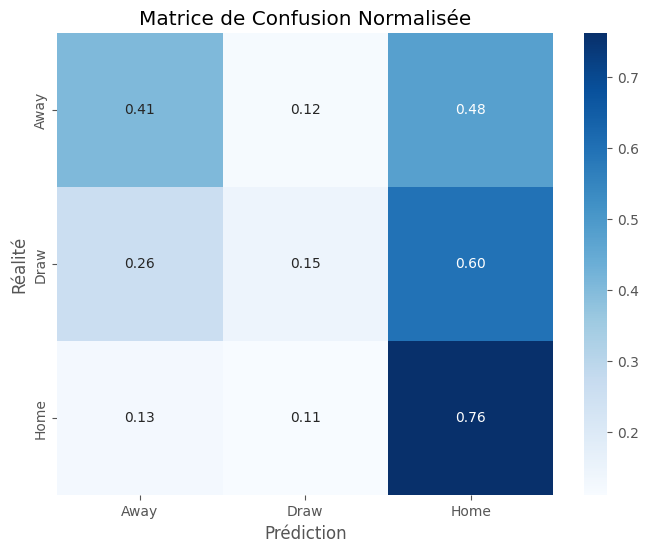

In [4]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.2f', xticklabels=['Away', 'Draw', 'Home'], yticklabels=['Away', 'Draw', 'Home'])
plt.title('Matrice de Confusion Normalisée')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

## 3. Importance des Features
Quelles sont les variables qui dictent le score ?

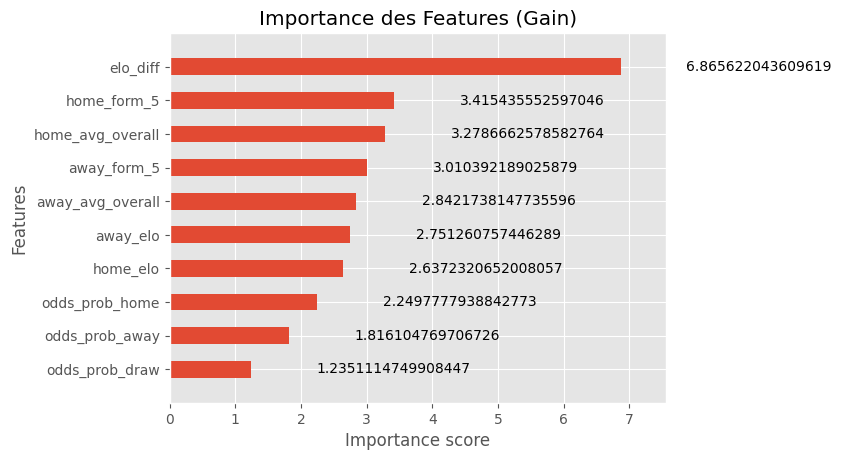

In [5]:
xgb.plot_importance(model, importance_type='gain', max_num_features=10, height=0.5)
plt.title('Importance des Features (Gain)')
plt.show()